## Introduction to CID for Multiclass Classification Problems

In [59]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import CID_numerical


### Loading a test dataset

The main difference from *Introduction_Binary_Classification* is that we just need to preprocess the dataset. In simple terms, if we consider a multiclass problem as $$f\colon \mathbb{R}^n \to \{0,1,\ldots,K\},$$
then it is sufficient to define $A\subset \{0,1,\ldots,K\}$ and $B=A^c$ and replace the target variable in the dataset with $0$ or $1$ whether $f(x)\in A$ or $f(x)\in B$. If we are interested in a specific value of the target, we could set $A=s$, where $s \in \{0,1,\ldots,K\}$ and $B=A^c$.

In [21]:
df = pd.read_csv('mobile.csv')

print(df.head(5))

df['price_range'].unique() 

   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch_screen  wifi  price_

array([1, 2, 3, 0], dtype=int64)

Here, we have four range for the mobile price: 0,1,2,3. We are interested in understanding what makes a feature a very expensive mobile, so we set 3 to class 1 and the other three values (0,1,2) are set to class 0.

In [22]:
# We remove some columns: blue, for_g, touch_screen, three_g, wifi, sc_w, n_cores, sc_h, dual_sim

columns_to_remove = ['blue','dual_sim','four_g','n_cores','sc_h','sc_w','three_g','touch_screen','wifi']
df.drop(columns_to_remove, axis=1, inplace=True)

# Changing the classification
df['price_range'] = np.where(df['price_range']==3,1,0)

train_dataset, test_dataset, y_train, y_test = train_test_split(df, df['price_range'], test_size=0.8, random_state=42)
model = DecisionTreeClassifier()
x_train = train_dataset.drop('price_range', axis=1)
x_test = test_dataset.drop('price_range', axis=1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.91125


### CID Explanation

In [28]:
CID_explainer = CID_numerical.CIDNumericalExplainer(train_dataset,model,
                                                    cf_method='neighbors',
                                                    features_names=x_train.columns.tolist(),
                                                    target_ft_name='price_range')

# Instance we want to explain
instance = x_train[5:6] # <- has a classification of 1

feature_importances = CID_explainer.explain_instance(instance)

In [42]:
x_train.columns

Index(['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep',
       'mobile_wt', 'pc', 'px_height', 'px_width', 'ram', 'talk_time'],
      dtype='object')

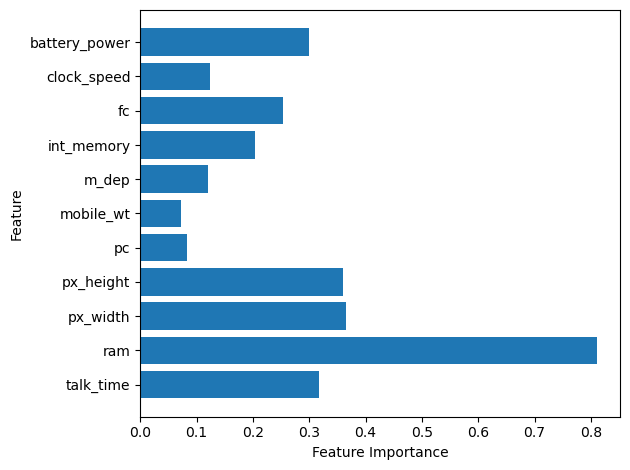

In [58]:
CID_explainer.visualize_feature_importances(feature_importances,output=False)